In [1]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import random, glob, os

# Путь к тестовым изображениям
test_images_dir = "../data/lab6/test_images"
image_files = glob.glob(os.path.join(test_images_dir, "*.*"))

# Выбираем случайное изображение
selected_image_path = random.choice(image_files)
print("Выбрана тестовая картинка:", selected_image_path)

Выбрана тестовая картинка: ../data/lab6/test_images/people23.jpg


In [2]:

# Загружаем модель YOLOv5s (предобученная на COCO)
model = YOLO('yolov5s.pt')

# Выполняем инференс
results = model(selected_image_path)

# Подсчитываем, сколько объектов класса "person" обнаружено
# Предполагается, что модель предсказывает класс 'person' с индексом, соответствующим COCO (обычно 0 или 1, проверь в результатах модели)
person_count = 0
for box in results[0].boxes:
    # box.cls содержит класс; преобразуем его в int
    cls = int(box.cls[0])
    # В COCO класс "person" обычно имеет индекс 0
    if cls == 0:
        person_count += 1

print("Количество обнаруженных людей:", person_count)

PRO TIP 💡 Replace 'model=yolov5s.pt' with new 'model=yolov5su.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.


image 1/1 /home/sitavlas/PycharmProjects/MachineLearningLab/LB6/../data/lab6/test_images/people23.jpg: 384x640 23 persons, 4 bottles, 2 wine glasss, 3 cups, 1 bowl, 2 dining tables, 20.4ms
Speed: 4.7ms preprocess, 20.4ms inference, 171.7ms postprocess per image at shape (1, 3, 384, 640)
Количество обнаруженных людей: 23


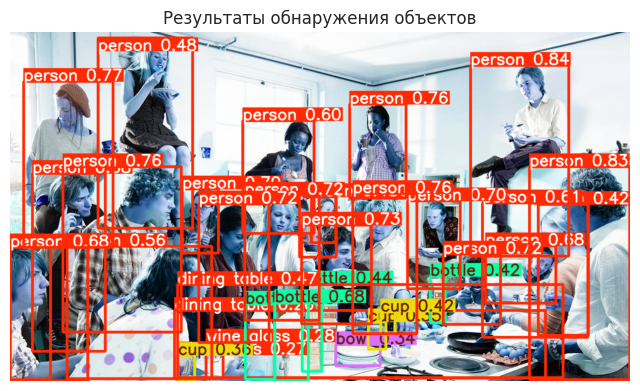

Количество обнаруженных людей: 23


In [3]:
# Визуализация результатов с ограничивающими рамками:
results[0].show()

# Отрисовка изображения с аннотациями через matplotlib:
rendered_image = results[0].plot()  # Используем метод plot(), который возвращает изображение с нанесёнными рамками
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 8))
plt.imshow(rendered_image)
plt.title("Результаты обнаружения объектов")
plt.axis("off")
plt.show()

# Подсчет объектов класса "person"
person_count = 0
for box in results[0].boxes:
    cls = int(box.cls[0])
    if cls == 0:  # В COCO класс "person" обычно имеет индекс 0
        person_count += 1

print("Количество обнаруженных людей:", person_count)
